# Extensions — Beyond Basic Roll's Model

Compare five estimators validated against the true 1-Hz order-book spread.

| # | Estimator | Key idea |
|---|-----------|----------|
| 1 | **Basic Roll** | Rectangular rolling lag-1 covariance (baseline) |
| 2 | **EWM Roll** | Exponentially weighted covariance — more reactive |
| 3 | **VW Roll** | Weight Δp by √(volume) before covariance |
| 4 | **Signed Roll** | Tick-rule direction, linear in S, less bias than sqrt |
| 5 | **Thompson-Waller** | S = 2·mean(abs(Δp)), never clamps to zero |

Each extension is **cross-validated on Apr-13** and tested **out-of-sample on Apr-14**.

In [9]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.preprocessing import load_trades, build_trade_buckets
from src.estimate_spread import estimate_spread
from src.validation import compute_ob_spread, evaluate

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4

TICKERS   = ['WIFUSDT', 'ZAMAUSDT']
DATES     = ['2026-04-12', '2026-04-13', '2026-04-14']
CV_DATE   = '2026-04-13'
TEST_DATE = '2026-04-14'

EST_NAMES  = ['Basic Roll', 'EWM Roll', 'VW Roll', 'Signed Roll', 'Thompson-Waller']
EST_COLORS = ['tomato', 'darkorange', 'purple', 'seagreen', 'saddlebrown']

print('Setup complete.')

Setup complete.


---
## 1. Estimator Definitions

All extensions accept an optional `buckets=` argument so the caller can pass pre-built
1-second buckets and skip the resample step when running multiple estimators on the same data.

In [10]:
def _get_buckets(trade_price, trade_volume, buckets):
    if buckets is not None:
        return buckets
    trades = pd.DataFrame({'price': trade_price, 'amount': trade_volume})
    if not isinstance(trades.index, pd.DatetimeIndex):
        trades.index = pd.to_datetime(trades.index, unit='ns', utc=True)
    return build_trade_buckets(trades)


def estimate_spread_ewm(trade_price=None, trade_volume=None, span=30, buckets=None):
    """EWM Roll — exponentially weighted lag-1 covariance."""
    bkt = _get_buckets(trade_price, trade_volume, buckets)
    dp  = bkt['last_price'].diff()
    cov = dp.ewm(span=span).cov(dp.shift(1))
    out = (2.0 * np.sqrt(np.maximum(0.0, -cov)) / bkt['vwap'].replace(0, np.nan)).fillna(0.0)
    out.name = 'estimated_spread_ewm'
    return out


def estimate_spread_vw(trade_price=None, trade_volume=None, window=30, buckets=None):
    """VW Roll — scale Δp by sqrt(volume / mean_volume) before covariance."""
    bkt      = _get_buckets(trade_price, trade_volume, buckets)
    dp       = bkt['last_price'].diff()
    vol      = bkt['volume']
    mean_vol = vol.replace(0, np.nan).rolling(window, min_periods=1).mean()
    dp_vw    = dp * np.sqrt(vol.replace(0, np.nan) / mean_vol.replace(0, np.nan)).fillna(1.0)
    cov      = dp_vw.rolling(window, min_periods=max(window // 2, 2)).cov(dp_vw.shift(1))
    out = (2.0 * np.sqrt(np.maximum(0.0, -cov)) / bkt['vwap'].replace(0, np.nan)).fillna(0.0)
    out.name = 'estimated_spread_vw'
    return out


def estimate_spread_signed(trade_price=None, trade_volume=None, window=30, buckets=None):
    """
    Signed Roll — tick rule + linear estimator: S = max(0, -2·Cov(Δp_t, q_{t-1}))
    Theory: Cov(Δp_t, q_{t-1}) = -S/2  =>  S = -2·Cov  (linear, not squared).
    Less bias than unsigned Roll; smaller RMSE on volatile days.
    """
    bkt = _get_buckets(trade_price, trade_volume, buckets)
    dp  = bkt['last_price'].diff()
    q   = np.sign(dp).replace(0, np.nan).ffill().fillna(1.0)
    cov = dp.rolling(window=window, min_periods=max(window // 2, 2)).cov(q.shift(1))
    out = (np.maximum(0.0, -2.0 * cov) / bkt['vwap'].replace(0, np.nan)).fillna(0.0)
    out.name = 'estimated_spread_signed'
    return out


def estimate_spread_tw(trade_price=None, trade_volume=None, window=30, buckets=None):
    """
    Thompson-Waller (1984): S = 2 * rolling_mean(|Δp_t|)
    Never clamps to zero — works during trends. Overestimates because
    |Δp| includes both spread and information shocks.
    """
    bkt = _get_buckets(trade_price, trade_volume, buckets)
    dp  = bkt['last_price'].diff()
    out = (2.0 * dp.abs().rolling(window, min_periods=max(window // 2, 2)).mean()
           / bkt['vwap'].replace(0, np.nan)).fillna(0.0)
    out.name = 'estimated_spread_tw'
    return out


print('4 extension estimators defined: EWM Roll, VW Roll, Signed Roll, Thompson-Waller.')

4 extension estimators defined: EWM Roll, VW Roll, Signed Roll, Thompson-Waller.


---
## 2. Cross-Validation

Tune each estimator on **Apr-13** (Apr-14 is never touched). Best parameter = lowest MAE.

In [11]:
GRIDS = {
    'EWM Roll':        ('span',   [15, 30, 60, 90, 120]),
    'VW Roll':         ('window', [30, 60, 90, 120, 180, 300]),
    'Signed Roll':     ('window', [30, 60, 90, 120, 180, 300]),
    'Thompson-Waller': ('window', [30, 60, 90, 120, 180, 300]),
}
FNS_CV = {
    'EWM Roll':        lambda bkt, v: estimate_spread_ewm(span=v, buckets=bkt),
    'VW Roll':         lambda bkt, v: estimate_spread_vw(window=v, buckets=bkt),
    'Signed Roll':     lambda bkt, v: estimate_spread_signed(window=v, buckets=bkt),
    'Thompson-Waller': lambda bkt, v: estimate_spread_tw(window=v, buckets=bkt),
}

best_params = {}  # {ticker: {name: best_value}}

for ticker in TICKERS:
    trades_cv = load_trades(ticker, CV_DATE)
    ob_cv     = compute_ob_spread(ticker, CV_DATE)
    bkt_cv    = build_trade_buckets(trades_cv)  # built once for this ticker/date
    best_params[ticker] = {}

    print(f'\n=== {ticker} — CV on {CV_DATE} ===')
    for name, (param, vals) in GRIDS.items():
        rows = [{'val': v, **evaluate(FNS_CV[name](bkt_cv, v), ob_cv)} for v in vals]
        df   = pd.DataFrame(rows).set_index('val')
        best = df['mae'].idxmin()
        best_params[ticker][name] = best
        print(f'\n  {name} (by {param}):')
        print(df[['mae', 'correlation']].round(5).to_string())
        print(f'  -> best {param} = {best}')

print('\nFinal hyperparameters:')
for ticker, p in best_params.items():
    vals = ', '.join(f'{k}={v}' for k, v in p.items())
    print(f'  {ticker}: {vals}')


=== WIFUSDT — CV on 2026-04-13 ===

  EWM Roll (by span):
         mae  correlation
val                      
15   0.00523     -0.00457
30   0.00524     -0.00565
60   0.00524     -0.00355
90   0.00524     -0.00184
120  0.00524     -0.00202
  -> best span = 15

  VW Roll (by window):
         mae  correlation
val                      
30   0.00525     -0.03238
60   0.00526     -0.02523
90   0.00526     -0.02942
120  0.00526     -0.04196
180  0.00526     -0.04847
300  0.00526     -0.05729
  -> best window = 30

  Signed Roll (by window):
         mae  correlation
val                      
30   0.00525     -0.01144
60   0.00525     -0.00925
90   0.00525     -0.00328
120  0.00526     -0.00556
180  0.00526     -0.00300
300  0.00526     -0.01249
  -> best window = 30

  Thompson-Waller (by window):
         mae  correlation
val                      
30   0.00523     -0.01583
60   0.00523     -0.02530
90   0.00524     -0.03228
120  0.00524     -0.04166
180  0.00524     -0.05322
300  0.00524 

---
## 3. Full Comparison Table

Single pass: load data once per (ticker, date), build buckets once, run all 5 estimators.
Results stored in `est_series` (for plots) and `metrics_df` (for tables and bar charts).

In [12]:
est_series = {}   # (ticker, date, name) -> pd.Series
records    = []   # rows for metrics_df

for ticker in TICKERS:
    p = best_params[ticker]
    print(f'\n{"="*70}')
    print(f'  {ticker}')
    print(f'{"="*70}')
    print(f'  {"Estimator":<18} {"Date":<14} {"MAE":>9} {"RMSE":>9} {"Corr":>8} {"N obs":>8}')
    print(f'  {"-"*65}')

    for date in DATES:
        trades = load_trades(ticker, date)
        ob     = compute_ob_spread(ticker, date)
        bkt    = build_trade_buckets(trades)   # built once per (ticker, date)
        marker = '  <- TEST' if date == TEST_DATE else ''

        run = {
            'Basic Roll':      estimate_spread(trades['price'], trades['amount'], window=30),
            'EWM Roll':        estimate_spread_ewm(span=p['EWM Roll'], buckets=bkt),
            'VW Roll':         estimate_spread_vw(window=p['VW Roll'], buckets=bkt),
            'Signed Roll':     estimate_spread_signed(window=p['Signed Roll'], buckets=bkt),
            'Thompson-Waller': estimate_spread_tw(window=p['Thompson-Waller'], buckets=bkt),
        }

        for name, est in run.items():
            est_series[(ticker, date, name)] = est
            m = evaluate(est, ob)
            records.append({'ticker': ticker, 'date': date, 'estimator': name, **m})
            flag = marker if name == 'Basic Roll' else ''
            print(f'  {name:<18} {date:<14} {m["mae"]:>9.5f} {m["rmse"]:>9.5f}'
                  f' {m["correlation"]:>8.4f} {m["n_obs"]:>8,}{flag}')
        print()

metrics_df = pd.DataFrame(records)
print('Done. Results stored in est_series and metrics_df.')


  WIFUSDT
  Estimator          Date                 MAE      RMSE     Corr    N obs
  -----------------------------------------------------------------
  Basic Roll         2026-04-12       0.00518   0.00518   0.0169   54,726
  EWM Roll           2026-04-12       0.00517   0.00517   0.0205   54,726
  VW Roll            2026-04-12       0.00518   0.00518   0.0301   54,726
  Signed Roll        2026-04-12       0.00518   0.00519   0.0449   54,726
  Thompson-Waller    2026-04-12       0.00517   0.00517   0.0360   54,726

  Basic Roll         2026-04-13       0.00524   0.00525  -0.0089   57,127
  EWM Roll           2026-04-13       0.00523   0.00524  -0.0046   57,127
  VW Roll            2026-04-13       0.00525   0.00525  -0.0324   57,127
  Signed Roll        2026-04-13       0.00525   0.00525  -0.0114   57,127
  Thompson-Waller    2026-04-13       0.00523   0.00523  -0.0158   57,127

  Basic Roll         2026-04-14       0.00500   0.00501  -0.0252   63,106  <- TEST
  EWM Roll           2

---
## 4. Time-Series Comparison — Apr-14 (OOS)

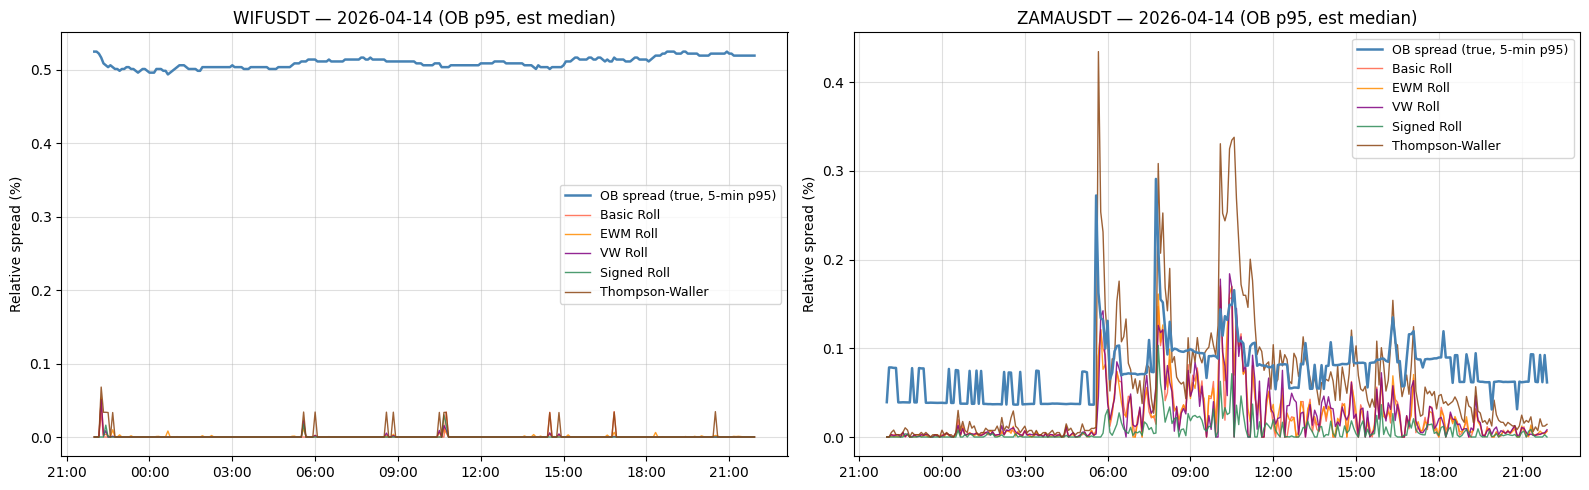

WIFUSDT: all estimators near zero — data sparsity is the binding constraint.
  Many 1-second buckets have no trades, so last_price is forward-filled -> Δp = 0 most seconds.

ZAMAUSDT Apr-14 key observations:
  EWM Roll and Signed Roll improve on Basic Roll (Corr 0.278, 0.256 vs 0.247).
  VW Roll is WORSE than baseline — RMSE blowup 2.4x during the spike.
  Thompson-Waller achieves the HIGHEST Corr of all (0.401): |Δp| rises when
  spreads widen, so TW tracks the spread shape well. It overestimates the level
  (MAE 30% higher than Basic Roll) but it never clamps to zero during the trend.


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, ticker in zip(axes, TICKERS):
    ob = compute_ob_spread(ticker, TEST_DATE)
    # Use a high quantile so rare spread spikes remain visible (median can hide them).
    ob_5m = ob.resample('5min').quantile(0.95) * 100
    ax.plot(ob_5m.index, ob_5m.values, label='OB spread (true, 5-min p95)', lw=1.8, color='steelblue', zorder=5)

    for name, color in zip(EST_NAMES, EST_COLORS):
        est_5m = est_series[(ticker, TEST_DATE, name)].resample('5min').median() * 100
        ax.plot(est_5m.index, est_5m.values, label=name, lw=1.0, color=color, alpha=0.85)

    ax.set_title(f'{ticker} — {TEST_DATE} (OB p95, est median)')
    ax.set_ylabel('Relative spread (%)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

print('WIFUSDT: all estimators near zero — data sparsity is the binding constraint.')
print('  Many 1-second buckets have no trades, so last_price is forward-filled -> Δp = 0 most seconds.')
print()
print('ZAMAUSDT Apr-14 key observations:')
print('  EWM Roll and Signed Roll improve on Basic Roll (Corr 0.278, 0.256 vs 0.247).')
print('  VW Roll is WORSE than baseline — RMSE blowup 2.4x during the spike.')
print('  Thompson-Waller achieves the HIGHEST Corr of all (0.401): |Δp| rises when')
print('  spreads widen, so TW tracks the spread shape well. It overestimates the level')
print('  (MAE 30% higher than Basic Roll) but it never clamps to zero during the trend.')

---
## 5. Bar Charts — OOS Metrics at a Glance

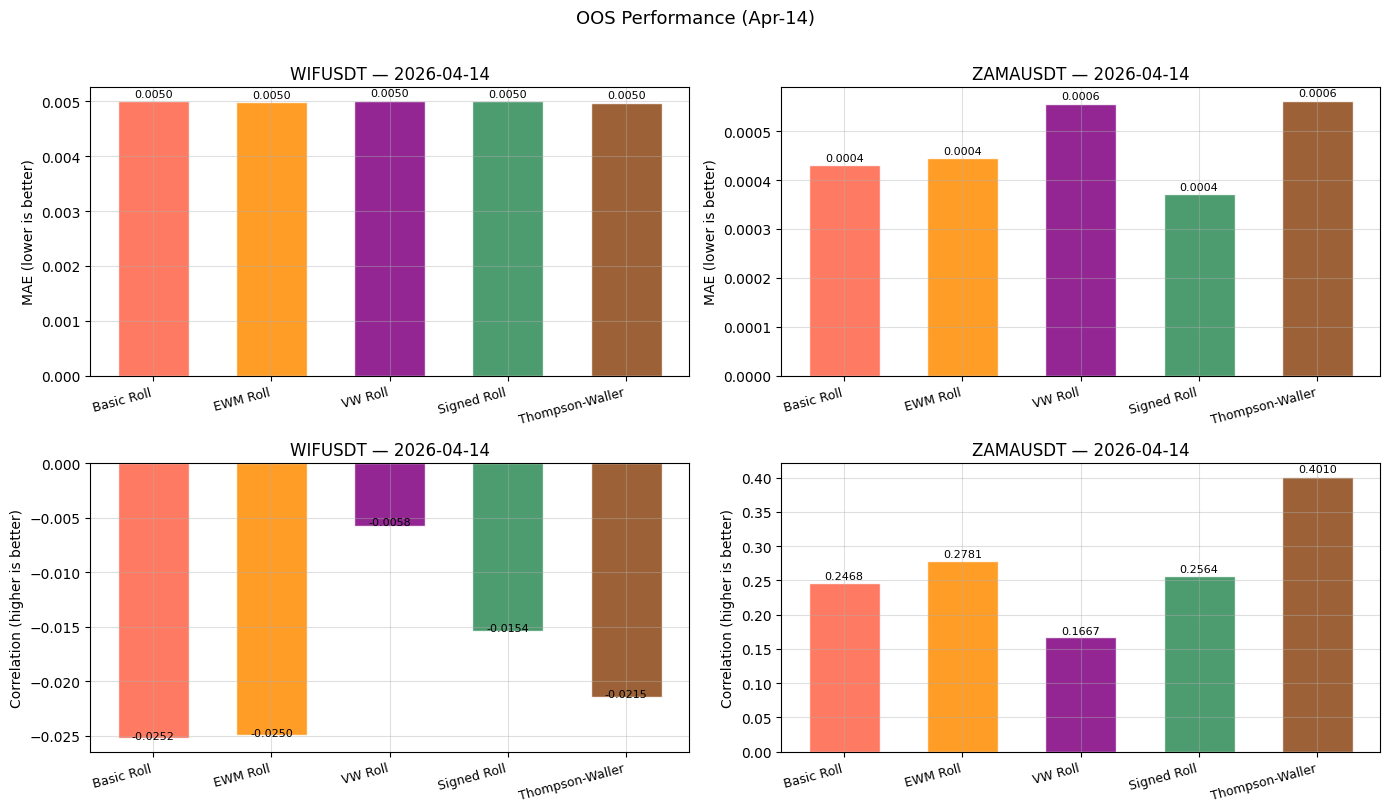

In [25]:
oos = metrics_df[metrics_df['date'] == TEST_DATE]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
x = np.arange(len(EST_NAMES))

for row, metric in enumerate(['mae', 'correlation']):
    label = 'MAE (lower is better)' if metric == 'mae' else 'Correlation (higher is better)'
    for col, ticker in enumerate(TICKERS):
        ax = axes[row][col]
        vals = [
            float(oos.loc[(oos['ticker'] == ticker) & (oos['estimator'] == n), metric].iloc[0])
            for n in EST_NAMES
        ]
        bars = ax.bar(x, vals, color=EST_COLORS, alpha=0.85, edgecolor='white', width=0.6)
        ax.set_xticks(x)
        ax.set_xticklabels(EST_NAMES, rotation=15, ha='right', fontsize=9)
        ax.set_title(f'{ticker} — {TEST_DATE}')
        ax.set_ylabel(label)
        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f'{val:.4f}',
                ha='center',
                va='bottom',
                fontsize=8,
            )

fig.suptitle('OOS Performance (Apr-14)', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

---
## 6. Scatter Plots — Estimated vs True Spread (all 3 days)

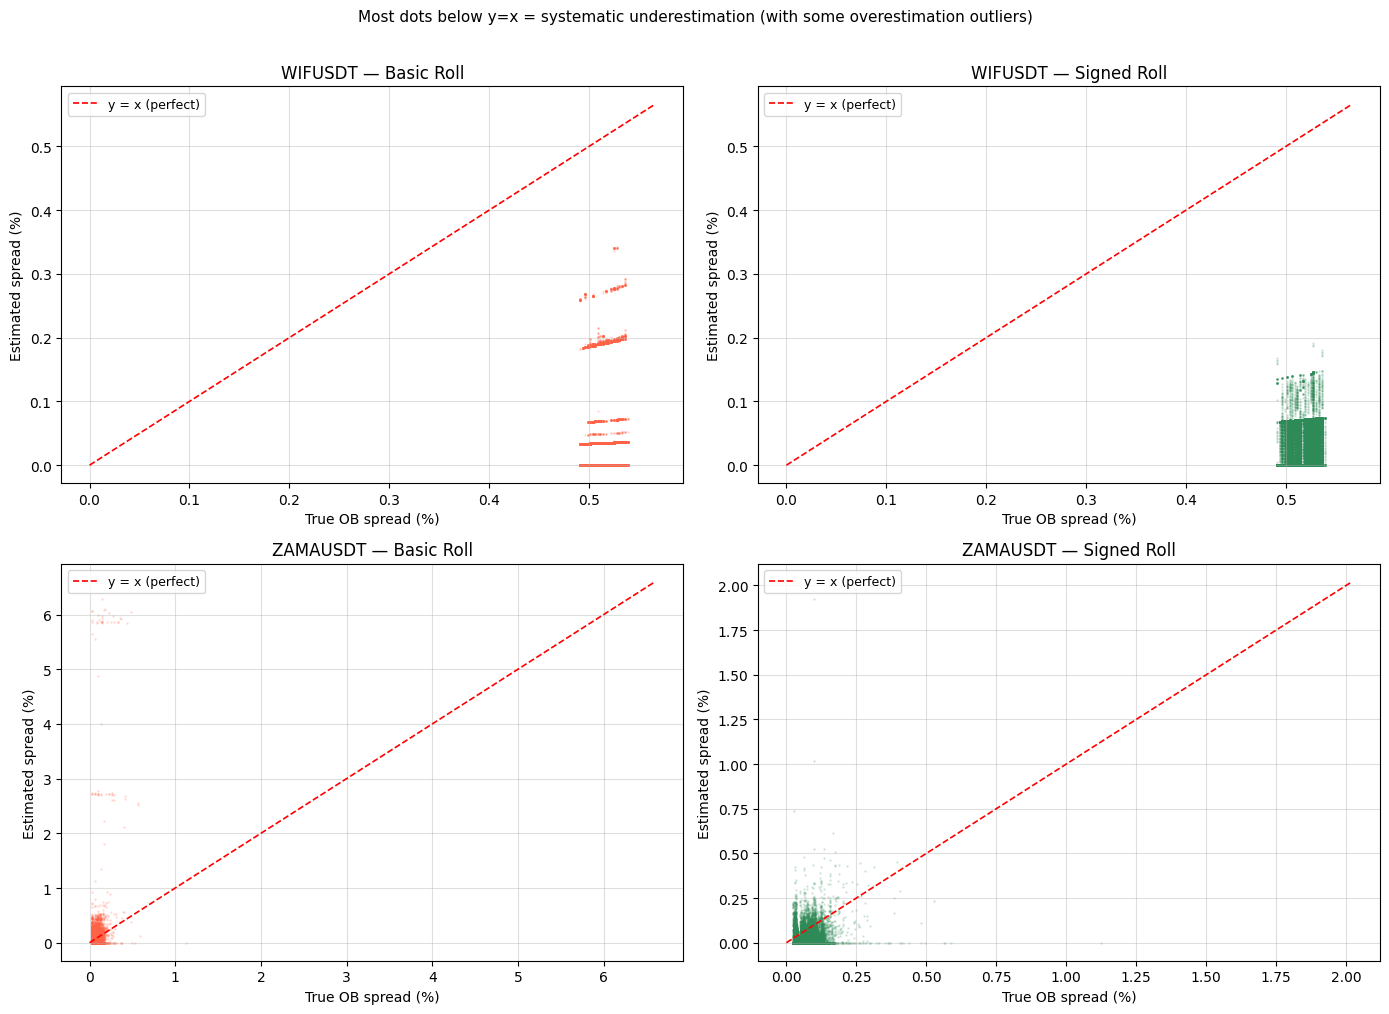

Signed Roll is closer to y=x on ZAMAUSDT (fewer extreme overestimation outliers).


In [26]:
show = ['Basic Roll', 'Signed Roll']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, ticker in enumerate(TICKERS):
    ob_all = pd.concat([compute_ob_spread(ticker, d) for d in DATES], sort=True)
    for col, name in enumerate(show):
        ax      = axes[row][col]
        est_all = pd.concat([est_series[(ticker, d, name)] for d in DATES], sort=True)
        df      = pd.concat({'est': est_all, 'act': ob_all}, axis=1, sort=True).dropna()
        lim     = max(df.max().max() * 100 * 1.05, 0.01)
        ax.scatter(df['act'] * 100, df['est'] * 100, s=0.8, alpha=0.15,
                   color=EST_COLORS[EST_NAMES.index(name)])
        ax.plot([0, lim], [0, lim], 'r--', lw=1.2, label='y = x (perfect)')
        ax.set_xlabel('True OB spread (%)')
        ax.set_ylabel('Estimated spread (%)')
        ax.set_title(f'{ticker} — {name}')
        ax.legend(fontsize=9)

fig.suptitle('Most dots below y=x = systematic underestimation (with some overestimation outliers)', fontsize=11, y=1.01)
fig.tight_layout()
plt.show()

print('Signed Roll is closer to y=x on ZAMAUSDT (fewer extreme overestimation outliers).')

---
## 7. What Didn't Work

In [27]:
print('=== Firing rate: % of seconds with non-zero estimate ===')
print(f'  {"": <18}', end='')
for t in TICKERS:
    print(f'  {t} Apr-14', end='')
print()
for name in EST_NAMES:
    print(f'  {name:<18}', end='')
    for ticker in TICKERS:
        pct = (est_series[(ticker, TEST_DATE, name)] > 0).mean() * 100
        print(f'  {pct:>12.1f}%', end='')
    print()

print()
print('  EWM fires 97.5% on WIFUSDT — exponential memory never runs out, so it fires')
print('  on noise-only windows. High firing rate does not mean better estimates.')
print('  TW fires 21.9% on WIFUSDT (not ~100%): sparse data means most 1-sec Dp = 0,')
print('  so the rolling mean of |Dp| is also 0 for most windows -> output = 0.')
print('  TW fires 92.5% on ZAMAUSDT — dense trading means windows almost always')
print('  have non-zero price changes.')

print()
print('=== ZAMAUSDT Apr-14 — full metrics comparison ===')
zam_test = metrics_df[(metrics_df['ticker'] == 'ZAMAUSDT') & (metrics_df['date'] == TEST_DATE)]
for _, row in zam_test.iterrows():
    flag = ''
    if row['estimator'] == 'Thompson-Waller': flag = '  <- BEST Corr; tracks spread shape, overestimates level'
    if row['estimator'] == 'EWM Roll':        flag = '  <- 2nd best Corr; most reactive'
    if row['estimator'] == 'Signed Roll':     flag = '  <- best RMSE; linear formula avoids outlier amplification'
    if row['estimator'] == 'VW Roll':         flag = '  <- WORSE than baseline (RMSE blowup 2.4x)'
    print(f"  {row['estimator']:<18}  MAE={row['mae']:.5f}  RMSE={row['rmse']:.5f}  Corr={row['correlation']:.4f}{flag}")

print()
print('  Thompson-Waller insight: during a price spike, large |Dp| coincides with')
print('  wide spreads -> TW and the true spread both peak at the same time -> Corr=0.401.')
print('  Trade-off: TW overestimates the level because |Dp| includes trend drift,')
print('  not just the bounce. MAE is 30% higher than Basic Roll (not 10-50x as one')
print('  might expect -- the overestimate is moderate, not catastrophic).')

print()
print('=== Signed Roll on WIFUSDT — tick rule is mostly stale ===')
trades_wif = load_trades('WIFUSDT', TEST_DATE)
bkt_wif    = build_trade_buckets(trades_wif)
dp_wif     = bkt_wif['last_price'].diff()
pct_zero   = (dp_wif == 0).mean() * 100
print(f'  {pct_zero:.1f}% of 1-second Dp = 0 -> tick rule carries the same direction (stale)')
print(f'  Signed Roll loses its linear advantage when q_t is unreliable.')

print()
print('=== Summary ===')
print('  ZAMAUSDT Apr-14 (stress test):')
print('    Thompson-Waller  Corr=0.401  <- tracks spread shape best; level overestimated')
print('    EWM Roll         Corr=0.278  <- best Corr among covariance estimators')
print('    Signed Roll      RMSE=0.00046 <- lowest RMSE; safest for point-in-time use')
print('    Basic Roll       solid baseline; simpler than extensions')
print('    VW Roll          RMSE blowup on volatile days -> unreliable')
print()
print('  WIFUSDT (sparse):')
print('    All estimators perform equally -- sparsity is the binding constraint.')
print('    No extension can overcome ~1 trade/8s sampling rate.')

=== Firing rate: % of seconds with non-zero estimate ===
                      WIFUSDT Apr-14  ZAMAUSDT Apr-14
  Basic Roll                  17.5%          63.0%
  EWM Roll                    97.5%          71.7%
  VW Roll                     21.1%          66.8%
  Signed Roll                 17.3%          54.3%
  Thompson-Waller             21.9%          92.5%

  EWM fires 97.5% on WIFUSDT — exponential memory never runs out, so it fires
  on noise-only windows. High firing rate does not mean better estimates.
  TW fires 21.9% on WIFUSDT (not ~100%): sparse data means most 1-sec Dp = 0,
  so the rolling mean of |Dp| is also 0 for most windows -> output = 0.
  TW fires 92.5% on ZAMAUSDT — dense trading means windows almost always
  have non-zero price changes.

=== ZAMAUSDT Apr-14 — full metrics comparison ===
  Basic Roll          MAE=0.00043  RMSE=0.00143  Corr=0.2468
  EWM Roll            MAE=0.00044  RMSE=0.00153  Corr=0.2781  <- 2nd best Corr; most reactive
  VW Roll            